In [9]:
# Cell 1: Setup & imports
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)
BASE = Path("/kaggle/input/dataset-cat-dog/dataset")   # <- change here if needed
TRAIN_DIR = BASE / "training_set"
TEST_DIR  = BASE / "test_set"

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 123
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

print("BASE exists?", BASE.exists())
print("TRAIN_DIR exists?", TRAIN_DIR.exists())
print("TEST_DIR exists?", TEST_DIR.exists())


TensorFlow version: 2.18.0
BASE exists? True
TRAIN_DIR exists? True
TEST_DIR exists? True


In [10]:
# Cell 2: Quick preview of folders and a few filenames
def list_dir(path, n=10):
    if not path.exists(): 
        print(path, "does not exist")
        return
    items = sorted(list(path.iterdir()))
    print(f"Contents of {path}:")
    for it in items[:n]:
        print(" ", it.name, "(dir)" if it.is_dir() else "")

list_dir(BASE)
list_dir(TRAIN_DIR)
# show count in classes (if present)
if TRAIN_DIR.exists():
    for cls in sorted(TRAIN_DIR.iterdir()):
        if cls.is_dir():
            print(f"{cls.name}: {len(list(cls.glob('*.*')))} images")


Contents of /kaggle/input/dataset-cat-dog/dataset:
  test_set (dir)
  training_set (dir)
Contents of /kaggle/input/dataset-cat-dog/dataset/training_set:
  cats (dir)
  dogs (dir)
cats: 4000 images
dogs: 4000 images


In [12]:
# Cell 3: Create ImageDataGenerator and flow_from_directory generators
import traceback

# import with fallback
try:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    print("Using ImageDataGenerator from tensorflow.keras")
except Exception as e:
    try:
        from keras.preprocessing.image import ImageDataGenerator
        print("Using ImageDataGenerator from standalone keras")
    except Exception:
        print("Failed to import ImageDataGenerator; traceback:")
        traceback.print_exc()
        raise

# parameters (confirm matches Cell 1)
IMG_SIZE = (150,150)
BATCH_SIZE = 32
SEED = 123

# training augmentations + validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

print("Creating train_generator and val_generator from:", TRAIN_DIR)
train_generator = train_datagen.flow_from_directory(
    directory=str(TRAIN_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    directory=str(TRAIN_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED,
    shuffle=True
)

print("Train samples:", train_generator.samples, "Classes:", train_generator.class_indices)
print("Val samples:", val_generator.samples)

# test generator (optional) - uses rescale only and shuffle=False to keep filenames order
test_generator = None
if TEST_DIR.exists():
    test_datagen = ImageDataGenerator(rescale=1./255)
    try:
        test_generator = test_datagen.flow_from_directory(
            directory=str(TEST_DIR),
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='binary',
            shuffle=False
        )
        print("Test samples:", test_generator.samples, "Classes:", test_generator.class_indices)
    except Exception as e:
        print("Could not create test_generator automatically; error:")
        traceback.print_exc()
else:
    print("No test directory found at", TEST_DIR)


Using ImageDataGenerator from tensorflow.keras
Creating train_generator and val_generator from: /kaggle/input/dataset-cat-dog/dataset/training_set
Found 6400 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.
Train samples: 6400 Classes: {'cats': 0, 'dogs': 1}
Val samples: 1600
Found 2000 images belonging to 2 classes.
Test samples: 2000 Classes: {'cats': 0, 'dogs': 1}


In [13]:
# Cell 4: Build a simple CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, InputLayer

model = Sequential([
    InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,563,713 (36.48 MB)

 Trainable params: 9,563,713 (36.48 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Cell 5: Train using flow_from_directory generators
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_cats_dogs_flow.h5', save_best_only=True)
]

steps_per_epoch = max(1, train_generator.samples // train_generator.batch_size)
validation_steps = max(1, val_generator.samples // val_generator.batch_size)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Save final model
model.save("cats_vs_dogs_flow_model")
print("Saved model to cats_vs_dogs_flow_model")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.5408 - loss: 0.7342

200/200 ━━━━━━━━━━━━━━━━━━━━ 176s 867ms/step - accuracy: 0.5410 - loss: 0.7340 - val_accuracy: 0.5644 - val_loss: 0.6738
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.6248 - loss: 0.6555

200/200 ━━━━━━━━━━━━━━━━━━━━ 168s 838ms/step - accuracy: 0.6249 - loss: 0.6554 - val_accuracy: 0.6988 - val_loss: 0.5980
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.6741 - loss: 0.6183

200/200 ━━━━━━━━━━━━━━━━━━━━ 167s 836ms/step - accuracy: 0.6741 - loss: 0.6183 - val_accuracy: 0.7050 - val_loss: 0.5665
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 166s 829ms/step - accuracy: 0.7176 - loss: 0.5540 - val_accuracy: 0.6869 - val_loss: 0.5694
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.7472 - loss: 0.5071

...

200/200 ━━━━━━━━━━━━━━━━━━━━ 166s 829ms/step - accuracy: 0.8368 - loss: 0.3769 - val_accuracy: 0.8206 - val_loss: 0.3980
Epoch 13/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 167s 833ms/step - accuracy: 0.8301 - loss: 0.3642 - val_accuracy: 0.7962 - val_loss: 0.4445
Epoch 14/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 166s 831ms/step - accuracy: 0.8453 - loss: 0.3452 - val_accuracy: 0.8012 - val_loss: 0.4144
Epoch 15/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.8476 - loss: 0.3353

200/200 ━━━━━━━━━━━━━━━━━━━━ 165s 825ms/step - accuracy: 0.8476 - loss: 0.3353 - val_accuracy: 0.8300 - val_loss: 0.3825
Epoch 16/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.8548 - loss: 0.3307

200/200 ━━━━━━━━━━━━━━━━━━━━ 165s 825ms/step - accuracy: 0.8548 - loss: 0.3307 - val_accuracy: 0.8306 - val_loss: 0.3733
Epoch 17/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.8730 - loss: 0.3087

200/200 ━━━━━━━━━━━━━━━━━━━━ 165s 827ms/step - accuracy: 0.8729 - loss: 0.3088 - val_accuracy: 0.8319 - val_loss: 0.3722
Epoch 18/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 164s 821ms/step - accuracy: 0.8610 - loss: 0.3106 - val_accuracy: 0.8231 - val_loss: 0.4140
Epoch 19/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 165s 823ms/step - accuracy: 0.8777 - loss: 0.2919 - val_accuracy: 0.8238 - val_loss: 0.3899
Epoch 20/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 168s 839ms/step - accuracy: 0.8837 - loss: 0.2693 - val_accuracy: 0.8400 - val_loss: 0.3975


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=cats_vs_dogs_flow_model.

In [15]:
model.save("cats_vs_dogs_flow_model.h5")
print("Model saved successfully!")


Model saved successfully!


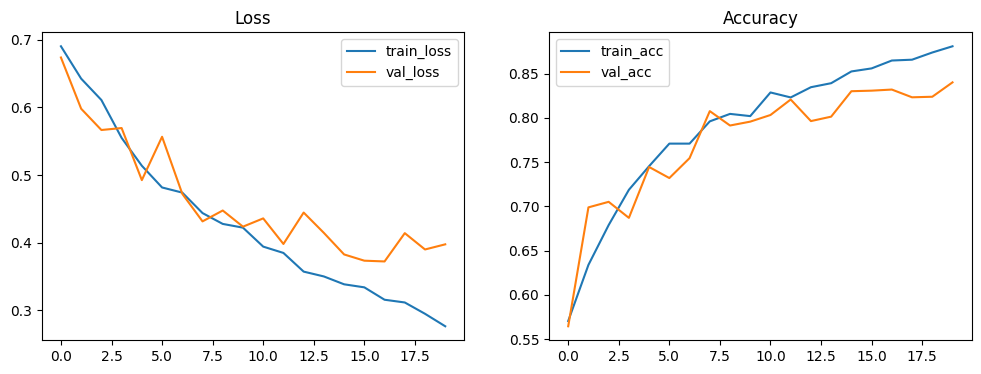

In [16]:
# Cell 6: Plot training/validation loss & accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("Accuracy")

plt.show()


63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 262ms/step - accuracy: 0.8331 - loss: 0.4127
Test loss: 0.4148, Test accuracy: 0.8355
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step


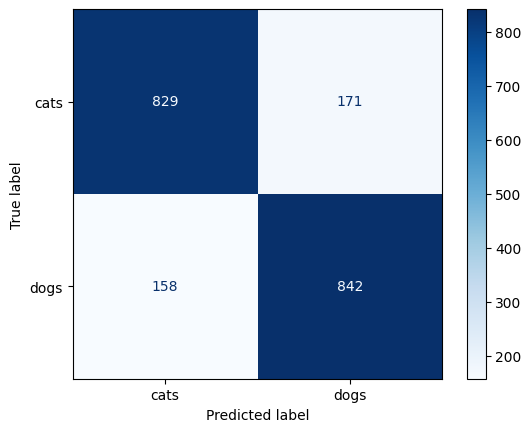

              precision    recall  f1-score   support

        cats       0.84      0.83      0.83      1000
        dogs       0.83      0.84      0.84      1000

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [17]:
# Cell 7: Evaluate and confusion matrix using test_generator (if available)
if test_generator is None:
    print("No test_generator available. Skipping test evaluation.")
else:
    # Evaluate
    test_steps = (test_generator.samples + test_generator.batch_size - 1) // test_generator.batch_size
    test_loss, test_acc = model.evaluate(test_generator, steps=test_steps)
    print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

    # Predictions: reset generator to start from first image
    test_generator.reset()
    preds = model.predict(test_generator, steps=test_steps)
    y_pred = (preds.ravel() > 0.5).astype(int)[:test_generator.samples]
    y_true = test_generator.classes[:len(y_pred)]

    # Confusion matrix & classification report
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(train_generator.class_indices.keys()))
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

    print(classification_report(y_true, y_pred, target_names=list(train_generator.class_indices.keys())))


In [25]:
def predict_single_image(img_path, model=model, img_size=IMG_SIZE):
    img = kimage.load_img(img_path, target_size=img_size)
    arr = kimage.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    p_dog = model.predict(arr)[0][0]     # model predicts dog probability
    p_cat = 1 - p_dog

    label = "dog" if p_dog > 0.5 else "cat"

    print(f"Prediction: {label}")
    print(f"Cat probability = {p_cat:.4f}")
    print(f"Dog probability = {p_dog:.4f}")

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{label}  (cat={p_cat:.2f}, dog={p_dog:.2f})")
    plt.show()

    return p_cat, p_dog, label


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction: dog
Cat probability = 0.0251
Dog probability = 0.9749


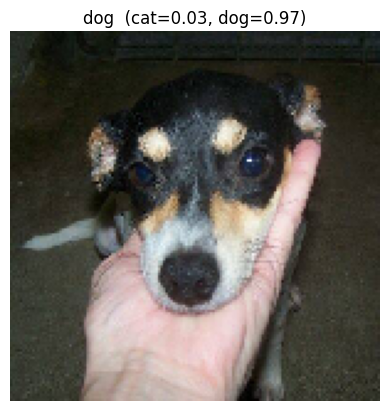

In [30]:
p_cat, p_dog, label = predict_single_image(
    "/kaggle/input/dataset-cat-dog/dataset/test_set/dogs/dog.4016.jpg",
    model=model
)


In [31]:
import os
print(os.listdir("/kaggle/working"))


['.virtual_documents', 'cats_vs_dogs_flow_model.h5', 'best_cats_dogs_flow.h5']


In [33]:
# Cell: convert H5 model to TFLite (float16 quantization)
import tensorflow as tf
from tensorflow.keras.models import load_model
import os

h5_path = "/kaggle/working/cats_vs_dogs_flow_model.h5"
tflite_path = "/kaggle/working/cats_vs_dogs_model_float16.tflite"

# load Keras model
model = load_model(h5_path)

# converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# try float16 quantization (good trade-off accuracy vs size)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

# save
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

# show size
print("H5 size (MB):", os.path.getsize(h5_path) / (1024*1024))
print("TFLite (float16) size (MB):", os.path.getsize(tflite_path) / (1024*1024))


INFO:tensorflow:Assets written to: /tmp/tmpcqkksfxl/assets


INFO:tensorflow:Assets written to: /tmp/tmpcqkksfxl/assets


Saved artifact at '/tmp/tmpcqkksfxl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139599129916624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139599129907408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139599129913744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139599129908176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139599129907792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139599129913936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139599129914704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139599129917200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139599129915280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139599129918736: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1765461777.669647      47 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1765461777.669703      47 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


H5 size (MB): 109.49319458007812
TFLite (float16) size (MB): 18.24626922607422


I0000 00:00:1765461777.678292      47 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


In [34]:
import os
for f in os.listdir("/kaggle/working"):
    if f.endswith(".tflite") or f.endswith(".h5") or f.endswith(".keras"):
        print(f, "->", os.path.getsize("/kaggle/working/"+f)/(1024*1024), "MB")
# Also show /tmp saved artifact (from convert logs)
if os.path.exists("/tmp/tmpcqkksfxl"):
    print("/tmp/tmpcqkksfxl exists, contents:", os.listdir("/tmp/tmpcqkksfxl")[:20])


cats_vs_dogs_flow_model.h5 -> 109.49319458007812 MB
cats_vs_dogs_model_float16.tflite -> 18.24626922607422 MB
best_cats_dogs_flow.h5 -> 109.49319458007812 MB
